# ResNet-34 Encoder for StyleGAN2 Latent Space

This notebook fine-tunes a pre-trained ResNet-34 model to encode generated images back into their corresponding latent vectors ($\mathcal{W}$ and $\mathcal{W}^+$ space).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ExponentialLR
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

from dataclasses import dataclass
import pickle
import sys
from pathlib import Path

# Add stylegan2 directory to sys.path
PROJECT_DIR = Path.cwd().resolve()
STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
if str(STYLEGAN2_DIR) not in sys.path:
    sys.path.insert(0, str(STYLEGAN2_DIR))

from stylegan2 import *
from stylegan2.torch_utils.misc import get_device

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = get_device()
print(f"Using device: {device}")

Using device: mps


/Users/colin/Library/Mobile Documents/com~apple~CloudDocs/TelecomParis/2A/IMA/IM06/Project19.nosync/Latent-Space-Faces/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# StyleGAN2 pretrained model
model_path = 'models/ffhq.pkl'
with open(model_path, 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)

/var/folders/hg/lv0crlp97h743p37hwnn9v7h0000gn/T/ipykernel_84661/1637531588.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  G = pickle.load(f)['G_ema'].to(device)


Generator latent Z dimension: 512
Generator mapping output W shape: 18 x 512


# Dataset Preparation

In [ ]:
N = 4096
batch_size = 8

recreate_dataset = False  # Set to True to recreate the dataset, False to load existing dataset

## Creation of the Dataset

In [ ]:
import os
import PIL.Image

if recreate_dataset:
    output_dir = "dataset"
    os.makedirs(output_dir, exist_ok=True)
    images_dir = os.path.join(output_dir, "images")
    os.makedirs(images_dir, exist_ok=True)

    all_z = []
    all_w = []

    print(f"Generating {N} images...")
    for i in range(0, N, batch_size):
        bs = min(batch_size, N - i)
        
        with torch.no_grad():
            z = torch.randn([bs, G.z_dim], device=device)
            w = G.mapping(z, None)
            images = G.synthesis(w, noise_mode='const')
            
            images = (images + 1) * (255 / 2.0)
            images = images.clamp(0, 255).to(torch.uint8).cpu().numpy()
            
        all_z.append(z.cpu())
        all_w.append(w.cpu())
        
        for j in range(bs):
            idx = i + j
            # Convert NCHW to HWC for PIL
            img_hwc = images[j].transpose(1, 2, 0)
            PIL.Image.fromarray(img_hwc).save(os.path.join(images_dir, f'image_{idx:04d}.png'))
            
        if (i + bs) % 64 == 0:
            print(f"Generated {i + bs}/{N} images")

    all_z = torch.cat(all_z, dim=0)
    all_w = torch.cat(all_w, dim=0)

    torch.save(all_z, os.path.join(output_dir, 'z_vectors.pt'))
    torch.save(all_w, os.path.join(output_dir, 'w_vectors.pt'))

Generating 4096 images...
Generated 64/4096 images
Generated 128/4096 images
Generated 192/4096 images
Generated 256/4096 images
Generated 320/4096 images
Generated 384/4096 images
Generated 448/4096 images
Generated 512/4096 images
Generated 576/4096 images
Generated 640/4096 images
Generated 704/4096 images
Generated 768/4096 images
Generated 832/4096 images
Generated 896/4096 images
Generated 960/4096 images
Generated 1024/4096 images
Generated 1088/4096 images
Generated 1152/4096 images
Generated 1216/4096 images
Generated 1280/4096 images
Generated 1344/4096 images
Generated 1408/4096 images
Generated 1472/4096 images
Generated 1536/4096 images
Generated 1600/4096 images
Generated 1664/4096 images
Generated 1728/4096 images
Generated 1792/4096 images
Generated 1856/4096 images
Generated 1920/4096 images
Generated 1984/4096 images
Generated 2048/4096 images
Generated 2112/4096 images
Generated 2176/4096 images
Generated 2240/4096 images
Generated 2304/4096 images
Generated 2368/409

The dataset needs to be loaded per batchs of images to avoid memory issuers. The following code allows to load the dataset when needed.

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

class StyleGANDataset(Dataset):
    def __init__(self, data_dir="dataset", transform=None):
        """
        Custom Dataset to load generated images and their corresponding Z and W vectors.
        """
        self.images_dir = os.path.join(data_dir, "images")
        
        self.z_vectors = torch.load(os.path.join(data_dir, "z_vectors.pt"), weights_only=True)
        self.w_vectors = torch.load(os.path.join(data_dir, "w_vectors.pt"), weights_only=True)
        
        self.transform = transform
        self.num_samples = self.z_vectors.shape[0]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.images_dir, f"image_{idx:04d}.png")
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        # Get corresponding vectors
        z = self.z_vectors[idx]
        w = self.w_vectors[idx]
        
        return image, z, w

Loaded batch: Images torch.Size([8, 3, 224, 224]), Z torch.Size([8, 512]), W torch.Size([8, 18, 512])


In [ ]:
# Instantiate the dataset and dataloader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

stylegan_dataset = StyleGANDataset(data_dir="dataset", transform=transform)
dataloader = DataLoader(stylegan_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

# Load a single batch for testing
batch_images, batch_z, batch_w = next(iter(dataloader))
print(f"Loaded batch: Images {batch_images.shape}, Z {batch_z.shape}, W {batch_w.shape}")

### Encoder definition for fine-tuning
We use ResNet-34 and replace its last fully connected layer
The encoder predicts a SINGLE W vector (w_dim) and dynamically duplicates it num_ws times to represent "18 times the same W".

In [ ]:
class ResNetEncoder(nn.Module):
    def __init__(self, num_ws, w_dim):
        super().__init__()
        self.resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        
        self.children_list = list(self.resnet.children())
        N = len(self.children_list)
        
        # Freeze the N-1 first layers
        # This will freeze conv1 up to layer3, leaving layer4 and the new fc trainable.
        for child in self.children_list[:N-4]:
            for param in child.parameters():
                param.requires_grad = False
                
        # Unfreeze layer4
        for param in self.children_list[N-4].parameters():
            param.requires_grad = True

        # Replace the final layer
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(in_features, w_dim)
        
        self.num_ws = num_ws
        self.w_dim = w_dim
        
    def forward(self, x):
        base_w = self.resnet(x) # shape: (batch_size, w_dim)
        
        # Project from W to W+ by duplicating the base W vector num_ws times for the generator
        w_repeated = base_w.unsqueeze(1).repeat(1, self.num_ws, 1)
        return w_repeated

encoder = ResNetEncoder(G.mapping.num_ws, G.mapping.w_dim).to(device)
print(encoder)

ResNetEncoder(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4

criterion = nn.MSELoss()

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, encoder.parameters()), lr=learning_rate, weight_decay=weight_decay)

total_steps = len(dataloader) * epochs
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-6)

encoder.train()
print(f"Starting Fine-tuning on full dataset for {epochs} epochs...")

full_dataset_losses = []

for epoch in range(epochs):
    epoch_loss = 0.0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for batch_idx, (images, _, target_w) in enumerate(progress_bar):
        images, target_w = images.to(device), target_w.to(device)

        predicted_w = encoder(images)

        loss = criterion(predicted_w, target_w)

        optimizer.zero_grad()
        loss.backward()
        
        # clip gradients to avoid exploding gradients during finetuning
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        loss_item = loss.item()
        epoch_loss += loss_item
        full_dataset_losses.append(loss_item)
        
        progress_bar.set_postfix({
            "Loss": f"{loss_item:.4f}",
            "LR": f"{scheduler.get_last_lr()[0]:.2e}"
        })

    avg_epoch_loss = epoch_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{epochs}] completed. Average Loss: {avg_epoch_loss:.4f}")


Starting Fine-tuning on full dataset for 30 epochs...


Epoch 1/30: 100%|██████████| 512/512 [02:23<00:00,  3.58it/s, Loss=0.1325, LR=9.97e-04]


Epoch [1/30] completed. Average Loss: 0.1768


Epoch 2/30: 100%|██████████| 512/512 [02:21<00:00,  3.61it/s, Loss=0.1156, LR=9.89e-04]


Epoch [2/30] completed. Average Loss: 0.1505


...

Epoch [28/30] completed. Average Loss: 0.0380


Epoch 29/30: 100%|██████████| 512/512 [02:35<00:00,  3.29it/s, Loss=0.0362, LR=3.74e-06]


Epoch [29/30] completed. Average Loss: 0.0378


Epoch 30/30: 100%|██████████| 512/512 [02:35<00:00,  3.28it/s, Loss=0.0379, LR=1.00e-06]

Epoch [30/30] completed. Average Loss: 0.0376


## Plot training loss and save the model

Training on full dataset complete!


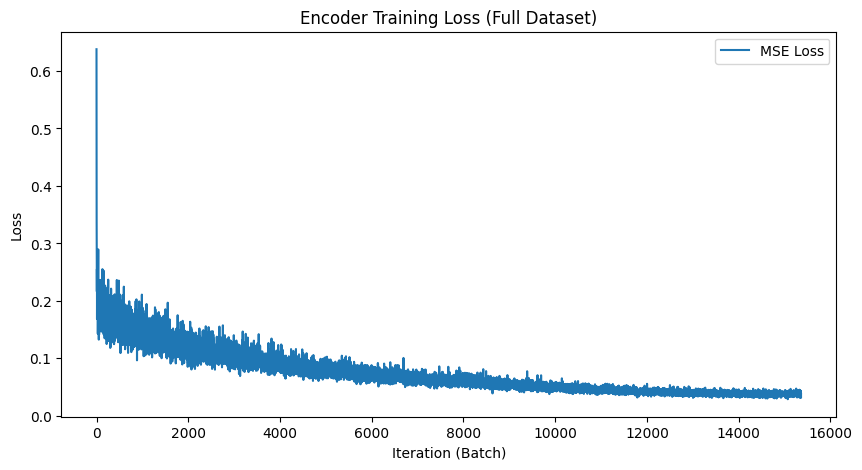

Full dataset encoder saved to models/resnet_encoder_full.pth


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(full_dataset_losses, label="MSE Loss")
plt.xlabel("Iteration (Batch)")
plt.ylabel("Loss")
plt.title("Encoder Training Loss (Full Dataset)")
plt.legend()
plt.show()

torch.save(encoder.state_dict(), "models/resnet_encoder_full.pth")

## Load saved model if not trained

In [ ]:
encoder_loaded = ResNetEncoder(G.mapping.num_ws, G.mapping.w_dim).to(device)
encoder_loaded.load_state_dict(torch.load("models/resnet_encoder_full.pth"))
encoder_loaded.eval()
encoder = encoder_loaded

Encoder loaded for inference.


# Inference and tests

## On synthetic images generated by StyleGAN2

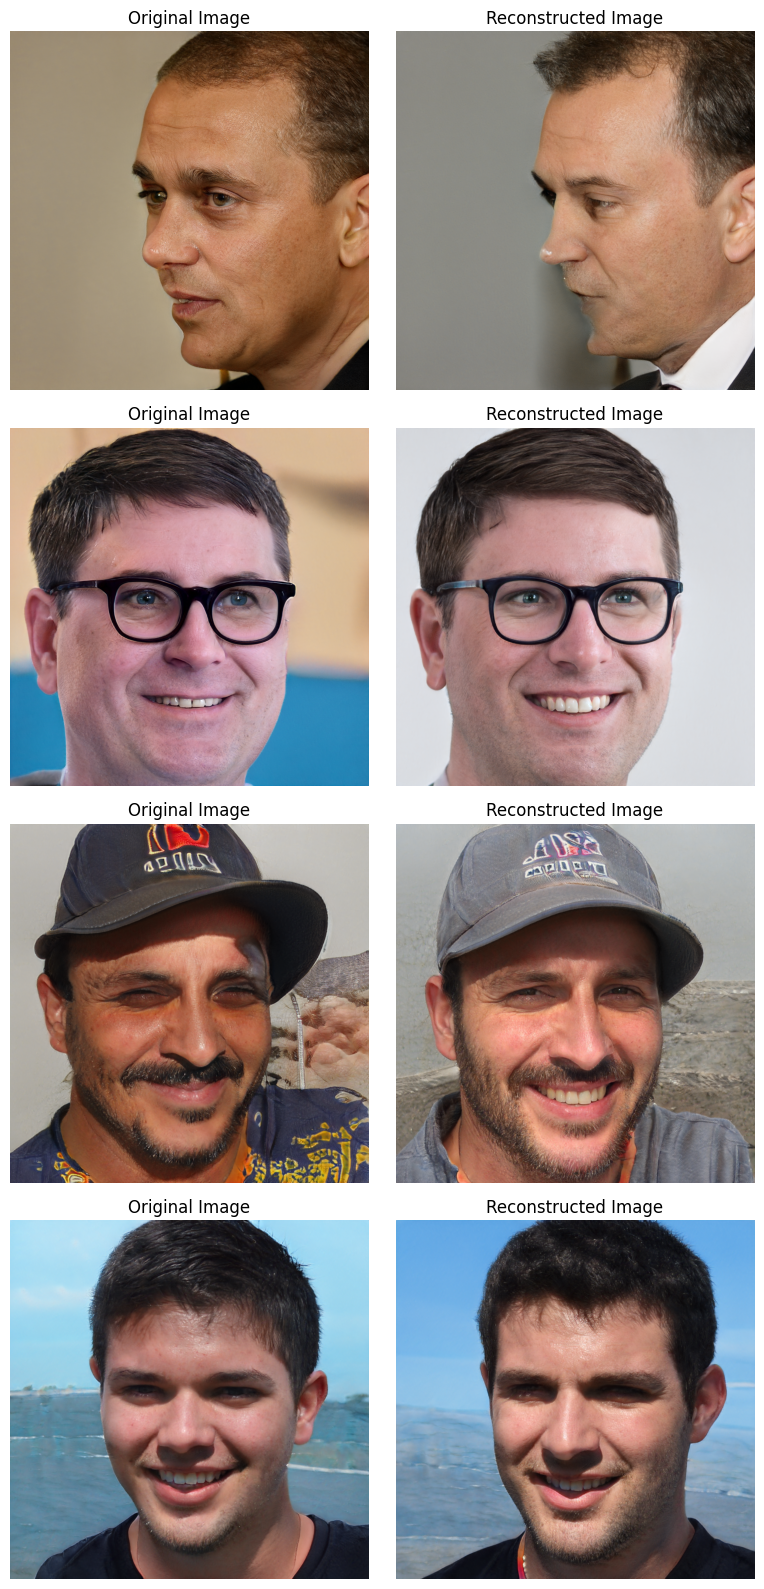

In [ ]:
from PIL import Image

test_batch_size = 4
with torch.no_grad():
    z_test = torch.randn([test_batch_size, G.z_dim], device=device)
    w_test = G.mapping(z_test, None)
    images_test = G.synthesis(w_test, noise_mode='const')
    
    # Images are in [-1, 1], move to [0, 255]
    images_test = (images_test + 1) * (255 / 2.0)
    images_test = images_test.clamp(0, 255).to(torch.uint8).cpu().numpy()


encoder.eval()
with torch.no_grad():
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224), antialias=True),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_images_pil = [Image.fromarray(img.transpose(1, 2, 0)) for img in images_test]
    test_images_tensor = torch.stack([preprocess(img) for img in test_images_pil]).to(device)
    
    predicted_w = encoder(test_images_tensor)
    reconstructed_images = G.synthesis(predicted_w, noise_mode='const')
    
    reconstructed_images = (reconstructed_images + 1) * (255 / 2.0)
    reconstructed_images = reconstructed_images.clamp(0, 255).to(torch.uint8).cpu().numpy()

# Visualize original and reconstructed images side by side
fig, axes = plt.subplots(test_batch_size, 2, figsize=(8, 4 * test_batch_size))
for i in range(test_batch_size):
    axes[i, 0].imshow(images_test[i].transpose(1, 2, 0))
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(reconstructed_images[i].transpose(1, 2, 0))
    axes[i, 1].set_title("Reconstructed Image")
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

## On real images

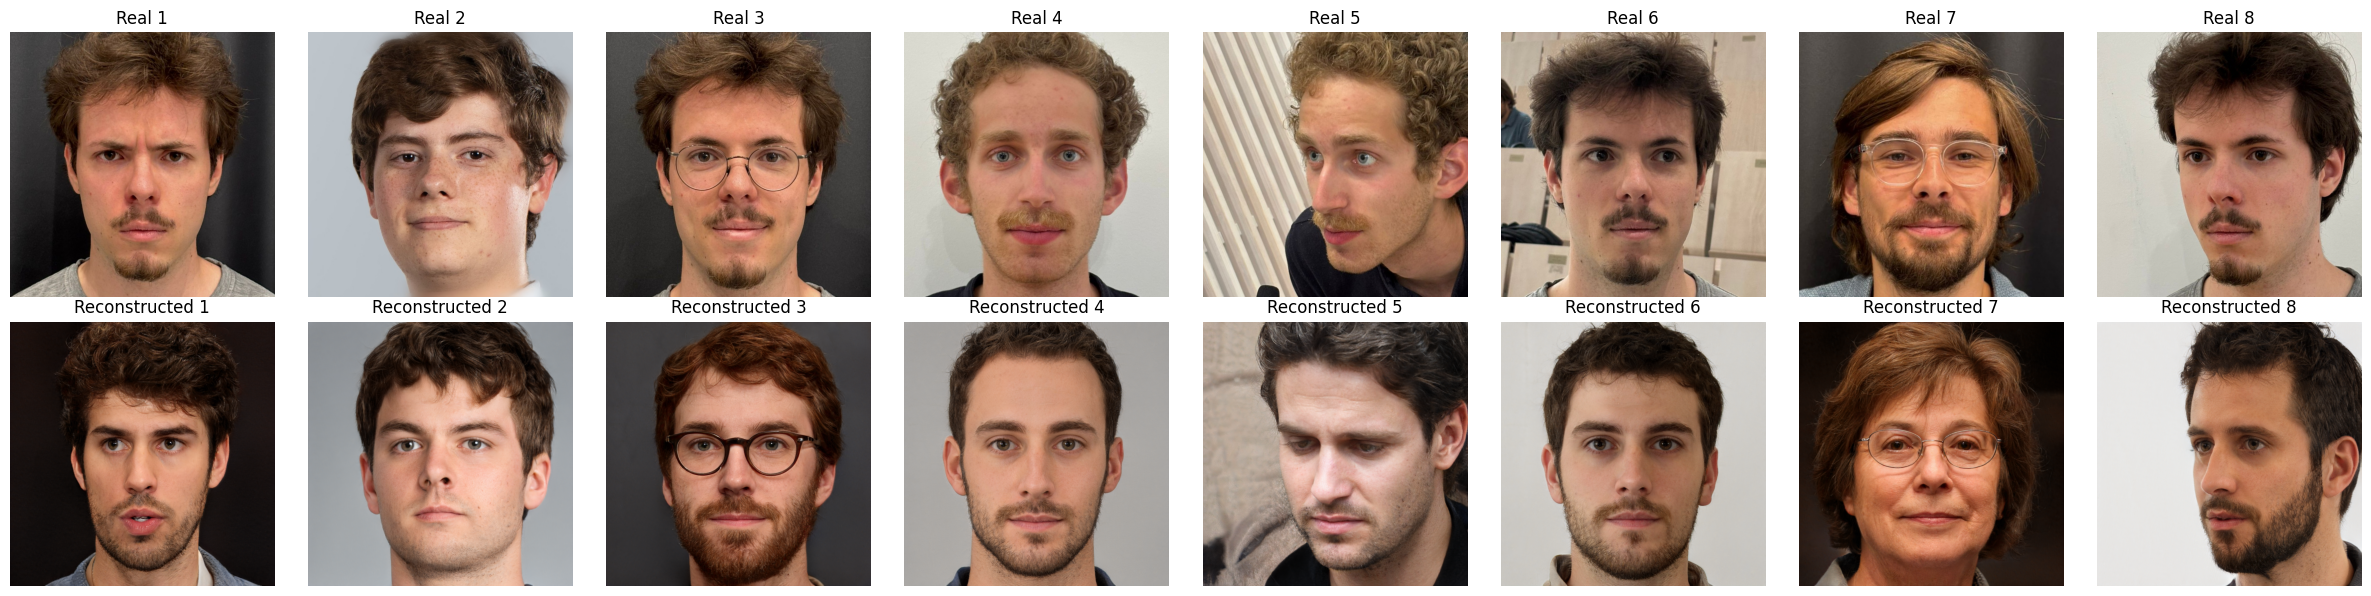

In [ ]:
num_images = 8
fig, axes = plt.subplots(2, num_images, figsize=(3 * num_images, 6))

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

encoder.eval()
for i in range(1, num_images + 1):
    real_image_path = f"real_images/test-16-06-{i}.jpeg"
    real_image = Image.open(real_image_path).convert("RGB")
    
    real_image_tensor = preprocess(real_image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        predicted_w_real = encoder(real_image_tensor)
        reconstructed_real_image = G.synthesis(predicted_w_real, noise_mode='const')

        reconstructed_real_image = (reconstructed_real_image + 1) * (255 / 2.0)
        reconstructed_real_image = reconstructed_real_image.clamp(0, 255).to(torch.uint8).cpu().numpy()[0].transpose(1, 2, 0)
    

    axes[0, i-1].imshow(real_image)
    axes[0, i-1].set_title(f"Real {i}")
    axes[0, i-1].axis('off')
    
    axes[1, i-1].imshow(reconstructed_real_image)
    axes[1, i-1].set_title(f"Reconstructed {i}")
    axes[1, i-1].axis('off')

plt.tight_layout()
plt.show()